In [29]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from mpl_toolkits.mplot3d import Axes3D
import time as tm
import matplotlib.animation as animation

## Estudiante: Darío Fernando García Ortega, 1004534662.

# Lab 4: Diffusion equation with FDM

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. <br>It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. <br>The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="350">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

#1. La solución estacionaria,
aquella en la que no hay dependencia del tiempo, por tanto la derivada temporal en la ecuación de difusión es nula y, en síntesis, hay que resolver Laplace. A través del método de diferencias finitas se tiene:


In [34]:
omega = 1.5  # factor Gauss Seidel 1<omega<2 que facilita la convergencia
max_iter = 700
Tcool = 0 # en °C
Thot = 900

# dimensiones de la placa (mm)
a, b = 20, 10
# intervalos
dx = dy = 0.1
# difusividad térmica del aluminio
D = 84.0
x = np.linspace(0,a,nx)
y = np.linspace(0,b,ny)

nx, ny = int(a/dx), int(b/dy) # separación de los puntos en la malla

dx2, dy2 = dx*dx, dy*dy
dt = dx2*dy2 / (2*D*(dx2 + dy2)) # dt máximo, utilizado luego para resolver en el tiempo

u0 = Tcool*np.ones((nx, ny)) ##### iniciando la malla #####

u = u0.copy()
u_yb = 100*np.sin(3*np.pi*x/a) ## condición inicial

for i in range(0,len(u)):
  u[i][len(u[0])-1] = u_yb[i] ## estableciendo la condición de frontera en uno de los bordes largos

st_t = tm.process_time()
for it in range(max_iter): # solucionando Laplace para estas condiciones de frontera
    u_old = u.copy()
    for i in range(1, len(x)-1):
        for j in range(1, len(y)-1):
            u_new = 0.25 * (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1])
            u[i, j] = (1 - omega) * u[i, j] + omega * u_new # actualizando únicamente los puntos interiores
end_t = tm.process_time()
print(f"Tiempo de cómputo = {(end_t-st_t)}")
u_df = u.copy()

Tiempo de cómputo = 28.921060280999995


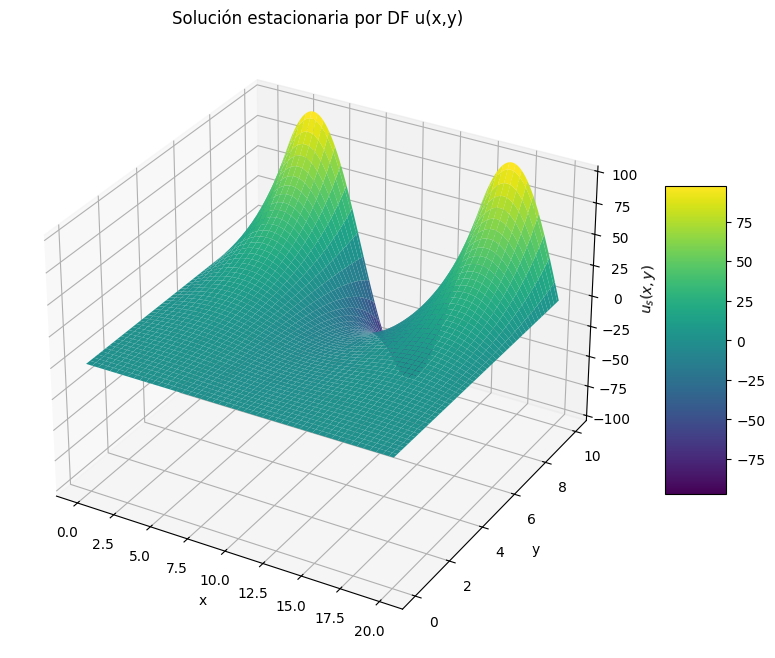

In [15]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

X_mesh, Y_mesh = np.meshgrid(x, y, indexing='ij')

surf = ax.plot_surface(X_mesh, Y_mesh, u, cmap='viridis', edgecolor='none')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel(rf'$u_s(x,y)$')
ax.set_title('Solución estacionaria por DF u(x,y)')

fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

## La solución estática analítica,

es de la forma (hecha a mano):

$$
u(x,y)=100 \sin(3\pi x/a) e^{3\pi(y-b)/a}
$$

implementada:

In [16]:
x = np.linspace(0,a,nx)
y = np.linspace(0,b,ny)
u = np.zeros((200,100))
for i in range(len(x)):
  for j in range(len(y)):
    u[i][j] = 100*np.sin(3*np.pi*x[i]/a)*np.exp(3*np.pi*(-b+y[j])/a)
u_a = u.copy()

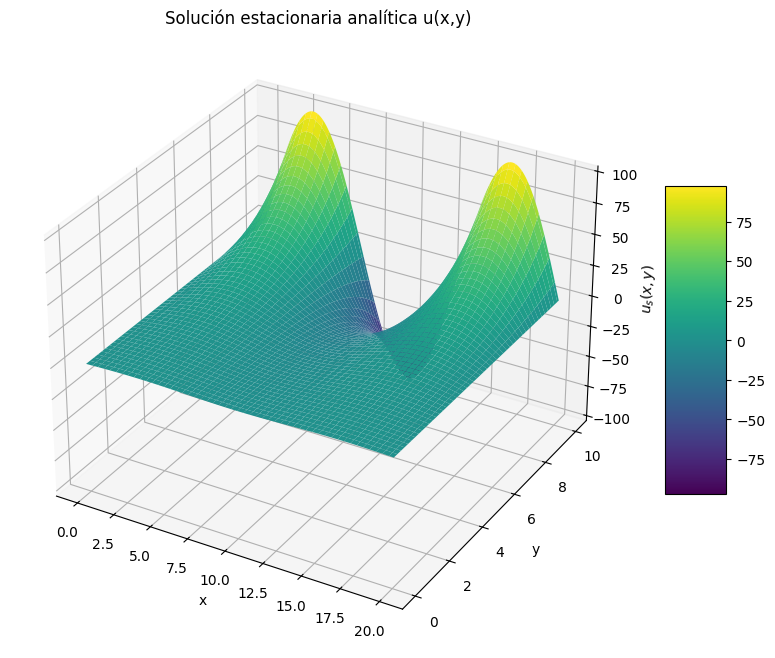

In [17]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

X_mesh, Y_mesh = np.meshgrid(x, y, indexing='ij')

surf = ax.plot_surface(X_mesh, Y_mesh, u, cmap='viridis', edgecolor='none')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel(rf'$u_s(x,y)$')
ax.set_title('Solución estacionaria analítica u(x,y)')

fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

## 2.

In [24]:
### Comparación ###
print(f"diferencia máxima = {abs((u_df-u_a).max())}")
print(f"con {max_iter} iteraciones y una malla de {ny*nx} puntos para la solución por diferencias finitas.")
print(f"La solución analítica contaba con un solo término dada su naturaleza, una superficie analítica \n que no necesita desarrollarse en términos de una serie.")

diferencia máxima = 0.8980772409005422
con 700 iteraciones y una malla de 20000 puntos para la solución por diferencias finitas.
La solución analítica contaba con un solo término dada su naturaleza, una superficie analítica 
 que no necesita desarrollarse en términos de una serie.


## 3 y 4. La solución dependiente del tiempo:

Implementando los algoritmos vistos en clase:

In [30]:
def Diffusion2D(V_ini,nx,ny,dt,D):

  u0 = V_ini.copy()

  for i in range(1, nx-1):
      for j in range(1, ny-1):
          uxx = (u0[i+1,j] - 2*u0[i,j] + u0[i-1,j])/dx2
          uyy = (u0[i,j+1] - 2*u0[i,j] + u0[i,j-1])/dy2
          u[i,j] = u0[i,j] + dt*D*(uxx + uyy)
  return u

u0 = Tcool*np.ones((nx, ny)) ##### iniciando la malla #####
u = u0.copy()

# Condiciones iniciales, bordes con temperatura 0°C, excepto el superior con
# u(x,b,t) = 100*sen(3*pi*x/a)
X = np.linspace(0,20,nx)
u_yb = 1000*np.sin(3*np.pi*X/a) ## cambié la amplitud de esta condición para notar mejor la evolución

for i in range(0,len(u)):
  u[i][len(u[0])-1] = u_yb[i] ## estableciendo la condición de frontera en uno de los bordes largos

def do_timestep(u0, u):
    # Propagate with forward-difference in time, central-difference in space
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D * dt * (
        (u0[2:, 1:-1] - 2 * u0[1:-1, 1:-1] + u0[:-2, 1:-1]) / dx2
        + (u0[1:-1, 2:] - 2 * u0[1:-1, 1:-1] + u0[1:-1, :-2]) / dy2
    )

    u0 = u.copy()
    return u0, u

n_pasos =150 ## iteraciones en el tiempo finito dt = 3e-5

# guardando los cuadros para la animación
cuadros = []
start = tm.process_time()
for m in range(n_pasos):
    u = Diffusion2D(u0,nx,ny,dt,D)
    u0 = u.copy()
    cuadros.append(u0.copy()) # guardando cada uno en el respectivo m
end = tm.process_time()
print(f"Tiempo de cómputo = {end-start}")

fig, ax = plt.subplots(figsize=(10,7))
im = ax.imshow(cuadros[0],cmap="hot",vmin=Tcool,vmax=Thot,interpolation="bilinear",)
ax.set_axis_off()

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("°C", labelpad=20)
fig.colorbar(im, cax=cbar_ax)

# función animación
def animate(i):
    im.set_array(cuadros[i])
    ax.set_title(f"Estado t = {np.round(dt*(i+1), 4)}, dt = {dt}, n = {i+1}")
    return [im]

anim = animation.FuncAnimation(fig, animate, frames=len(cuadros), interval=100, blit=True)

from IPython.display import HTML
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## Observaciones finales:

- Se tiene que obviar la imposibilidad física de las soluciones a la estática por las temperaturas negativas que implicarían y ajustar acorde, omití ese paso.

- La solución analítica puede presentar problemas de convergencia en las esquinas de la malla dadas algunas condiciones de frontera ligeramente distintas.

- El tiempo de cómputo de la solución a la estática por DF es muy exigente a 700 iteraciones, sería curioso ver cómo varían ambas cantidades.